In [1]:
import numpy as np
from scipy.sparse import csr_matrix, kron, identity

# ============================================================
# Single-site field operators from ladder operators
# ============================================================

def single_site_field_operators(nq, mu=1.0):

    # --------------------------------------------------------
    # Local Hilbert dimension
    # --------------------------------------------------------

    Nphi = 2**nq   # 64 for nq=6

    # --------------------------------------------------------
    # Ladder operator a
    # --------------------------------------------------------

    a = np.zeros((Nphi, Nphi), dtype=complex)

    for n in range(1, Nphi):

        a[n-1, n] = np.sqrt(n)

    # creation operator
    adag = a.conj().T

    # --------------------------------------------------------
    # Field operator
    #
    # Phi = (a + adag)/sqrt(2 mu)
    # --------------------------------------------------------

    Phi = (
        a + adag
    ) / np.sqrt(2 * mu)

    # --------------------------------------------------------
    # Conjugate momentum operator
    #
    # Pi = -i sqrt(mu/2) (a - adag)
    # --------------------------------------------------------

    Pi = (
        -1j
        * np.sqrt(mu / 2)
        * (a - adag)
    )

    # --------------------------------------------------------
    # Numerical Hermiticity cleanup
    # --------------------------------------------------------

    Phi = 0.5 * (Phi + Phi.conj().T)

    Pi = 0.5 * (Pi + Pi.conj().T)

    return csr_matrix(Phi), csr_matrix(Pi)


# ============================================================
# Two-site embedded operators
# ============================================================

def two_site_operators(nq, mu=1.0):

    # --------------------------------------------------------
    # Single-site operators
    # --------------------------------------------------------

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(
        Nphi,
        format='csr',
        dtype=complex
    )

    # --------------------------------------------------------
    # Site 0 operators
    # --------------------------------------------------------

    Phi0 = kron(Phi, I, format='csr')
    Pi0  = kron(Pi,  I, format='csr')

    # --------------------------------------------------------
    # Site 1 operators
    # --------------------------------------------------------

    Phi1 = kron(I, Phi, format='csr')
    Pi1  = kron(I, Pi,  format='csr')

    return Phi0, Pi0, Phi1, Pi1


# ============================================================
# Example
# ============================================================

nq = 4
mu = 1.0

Phi0, Pi0, Phi1, Pi1 = two_site_operators(
    nq,
    mu
)

print("Hilbert dimension =", Phi0.shape[0])

print("Phi0 shape =", Phi0.shape)
print("Pi0 shape  =", Pi0.shape)

print("Phi1 shape =", Phi1.shape)
print("Pi1 shape  =", Pi1.shape)

Hilbert dimension = 256
Phi0 shape = (256, 256)
Pi0 shape  = (256, 256)
Phi1 shape = (256, 256)
Pi1 shape  = (256, 256)


In [2]:
import numpy as np
from scipy.sparse import csr_matrix, kron, identity
from scipy.sparse.linalg import eigsh

# ============================================================
# Local single-site Hamiltonian
# ============================================================

def single_site_hloc(Phi, Pi, mI2, lam, f):

    Phi2 = Phi @ Phi
    Phi4 = Phi2 @ Phi2
    Pi2  = Pi @ Pi

    hloc = (
        0.5 * Pi2
        + 0.5 * mI2 * Phi2
        + (lam / 24.0) * Phi4
        + f * Phi
    )

    return hloc




In [3]:
# ============================================================
# Two-site local Hamiltonian
# ============================================================

def two_site_hloc(nq, mu=1.0,
                  mI2=1.0,
                  lam=1.0,
                  f=1e-3):

    # --------------------------------------------------------
    # Single-site operators
    # --------------------------------------------------------

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(Nphi, format='csr', dtype=complex)

    # --------------------------------------------------------
    # Single-site local Hamiltonian
    # --------------------------------------------------------

    hloc = single_site_hloc(Phi, Pi, mI2, lam, f)

    # --------------------------------------------------------
    # Two-site Hamiltonian
    # H = h ⊗ I + I ⊗ h
    # --------------------------------------------------------

    Hloc = (
        kron(hloc, I, format='csr')
        +
        kron(I, hloc, format='csr')
    )

    return Hloc




In [4]:
# ============================================================
# Exact ground state
# ============================================================

def ground_state(H):

    # smallest algebraic eigenvalue
    evals, evecs = eigsh(H, k=1, which='SA')

    E0 = evals[0]
    psi0 = evecs[:, 0]

    # normalize explicitly
    psi0 = psi0 / np.linalg.norm(psi0)

    return E0, psi0




In [9]:
# ============================================================
# Example
# ============================================================

nq   = 4
mu   = 1.0
mI2  = 1.0
lam  = 1.0
f    = 1e-3

Hloc = two_site_hloc(
    nq=nq,
    mu=mu,
    mI2=mI2,
    lam=lam,
    f=f
)

E0_loc, psi_loc = ground_state(Hloc)

print("Ground-state energy =", E0_loc)
print("State dimension     =", psi_loc.shape)
print("Norm                =", np.linalg.norm(psi_loc))

Ground-state energy = 1.0554714340962716
State dimension     = (256,)
Norm                = 1.0000000000000002


In [10]:
# ============================================================
# Convert scalar-field Hamiltonian to Pauli form

# ============================================================

from qiskit.quantum_info import Operator, SparsePauliOp

# ============================================================
# Build two-site Hamiltonian
# ============================================================

Hloc = two_site_hloc(
    nq=4,
    mu=1.0,
    mI2=1.0,
    lam=1.0,
    f=1e-5
)

# ============================================================
# Convert sparse matrix -> dense matrix
# ============================================================

H_dense = Hloc.toarray()

print("Dense Hamiltonian shape =", H_dense.shape)

# ============================================================
# Convert to Qiskit Operator
# ============================================================

H_op = Operator(H_dense)

# ============================================================
# Convert to SparsePauliOp
# ============================================================

print("\nConverting to Pauli representation...\n")

H_pauli = SparsePauliOp.from_operator(H_op)

# ============================================================
# Remove tiny coefficients
# ============================================================

H_pauli = H_pauli.simplify(atol=1e-10)

print("Done.")

# ============================================================
# Number of Pauli terms
# ============================================================

print("\nNumber of Pauli terms =", len(H_pauli))

# ============================================================
# Show first few Pauli terms
# ============================================================

print("\nFirst few Pauli terms:\n")

for pauli, coeff in zip(
    H_pauli.paulis[:10],
    H_pauli.coeffs[:10]
):

    print(f"{coeff:.6f} * {pauli}")

Dense Hamiltonian shape = (256, 256)

Converting to Pauli representation...

Done.

Number of Pauli terms = 111

First few Pauli terms:

24.062500+0.000000j * IIIIIIII
0.000019+0.000000j * IIIIIIIX
3.203275+0.000000j * IIIIIIXI
-0.031443+0.000000j * IIIIIIXZ
-0.687500+0.000000j * IIIIIIZI
-0.937500+0.000000j * IIIIIIZZ
0.833067+0.000000j * IIIIIXII
-0.083419+0.000000j * IIIIIXIZ
1.669265+0.000000j * IIIIIXXI
-0.166668+0.000000j * IIIIIXXZ


In [11]:
# ============================================================
# Remove identity offset
# ============================================================

coeffs = H_pauli.coeffs
paulis = H_pauli.paulis

new_coeffs = []
new_paulis = []

identity_shift = 0.0

for p, c in zip(paulis, coeffs):

    if str(p) == 'I' * nq:

        identity_shift += np.real(c)

    else:

        new_paulis.append(p)
        new_coeffs.append(c)

H_pauli_shifted = SparsePauliOp(
    new_paulis,
    coeffs=new_coeffs
)

print("Removed identity shift =", identity_shift)

print("Remaining Pauli terms =",
      len(H_pauli_shifted))

Removed identity shift = 0.0
Remaining Pauli terms = 111


In [12]:
# ============================================================
# Genuine Qiskit VQE on shifted Pauli Hamiltonian
# ============================================================

import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SPSA

from qiskit.primitives import StatevectorEstimator


# ============================================================
# Variational circuit
# ============================================================

def variational_circuit(nq, layers):

    qc = QuantumCircuit(nq)

    nparams = 2 * nq * layers

    params = ParameterVector("θ", nparams)

    p = 0

    for l in range(layers):

        # ----------------------------------------------------
        # Single-qubit rotations
        # ----------------------------------------------------

        for q in range(nq):

            qc.ry(params[p], q)
            qc.rz(params[p + 1], q)

            p += 2

        # ----------------------------------------------------
        # Entanglement layer
        # ----------------------------------------------------

        if l != layers - 1:

            # even bonds
            if l % 2 == 0:

                for q in range(0, nq - 1, 2):
                    qc.cz(q, q + 1)

            # odd bonds
            else:

                for q in range(1, nq - 1, 2):
                    qc.cz(q, q + 1)

    return qc


# ============================================================
# Ansatz
# ============================================================

nqubits = 8

# start modestly
layers = 8

ansatz = variational_circuit(
    nqubits,
    layers
)

# ============================================================
# Estimator
# ============================================================

estimator = StatevectorEstimator()

# ============================================================
# Optimizer
# ============================================================

optimizer = SPSA(
    maxiter=5000
)

# ============================================================
# VQE
# ============================================================
initial_point = 0.01 * np.random.randn(
    ansatz.num_parameters
)
vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    initial_point=initial_point
)

# ============================================================
# Run VQE
# ============================================================

print("\nRunning VQE...\n")

result = vqe.compute_minimum_eigenvalue(
    H_pauli_shifted
)

# ============================================================
# Shifted energy
# ============================================================

E_shifted = result.eigenvalue.real

# ============================================================
# Physical energy
# ============================================================

E_vqe = E_shifted + identity_shift

# ============================================================
# Optimal parameters
# ============================================================

optimal_params = result.optimal_parameters

# ============================================================
# Optimized circuit
# ============================================================

optimal_circuit = ansatz.assign_parameters(
    optimal_params
)

# ============================================================
# VQE state
# ============================================================

psi_vqe = Statevector.from_instruction(
    optimal_circuit
).data

# ============================================================
# Fidelity
# ============================================================

Fidelity = np.abs(
    np.vdot(psi_loc, psi_vqe)
)**2

# ============================================================
# Results
# ============================================================

print("\n================================")
print("Exact energy :", E0_loc)
print("VQE energy   :", E_vqe)
print("Energy error :", abs(E_vqe - E0_loc))
print("Fidelity     :", Fidelity)
print("Layers        :", layers)
print("Pauli terms   :", len(H_pauli_shifted))
print("================================")


Running VQE...


Exact energy : 1.0554714340962716
VQE energy   : 1.0695495510195965
Energy error : 0.014078116923324835
Fidelity     : 0.9965268355537765
Layers        : 8
Pauli terms   : 111


In [13]:
###### Exact Ground State Utility

# ============================================================
# Exact ground state from sparse Hamiltonian
# ============================================================

from scipy.sparse.linalg import eigsh


def exact_ground_state(H_sparse):

    evals, evecs = eigsh(H_sparse, k=1, which='SA')

    E0 = np.real(evals[0])

    psi0 = evecs[:, 0]
    psi0 = psi0 / np.linalg.norm(psi0)

    return E0, psi0


In [14]:
##### Fidelity Function

def fidelity(psi_exact, psi_vqe):

    return np.abs(np.vdot(psi_exact, psi_vqe))**2

In [15]:
# ============================================================
# Robust VQE with eigenstate tracking
# ============================================================
import numpy as np

from scipy.sparse import identity, kron

from qiskit.quantum_info import (
    Statevector,
    Operator,
    SparsePauliOp
)

from qiskit.primitives import StatevectorEstimator

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import L_BFGS_B
def run_robust_vqe(

    H_sparse,

    nq,

    layers,

    n_restarts,

    energy_tol,

    previous_state=None,

    previous_optimal_point=None
):

    nqubits = nq

    # --------------------------------------------------------
    # Exact ground state
    # --------------------------------------------------------

    E_exact, psi_exact = exact_ground_state(H_sparse)

    # --------------------------------------------------------
    # Convert Hamiltonian
    # --------------------------------------------------------

    H_dense = H_sparse.toarray()

    H_op = Operator(H_dense)

    H_pauli = SparsePauliOp.from_operator(H_op)

    coeffs = H_pauli.coeffs

    paulis = H_pauli.paulis

    new_coeffs = []

    new_paulis = []

    identity_shift = 0.0

    for p, c in zip(paulis, coeffs):

        if str(p) == 'I' * nqubits:

            identity_shift += np.real(c)

        else:

            new_paulis.append(p)

            new_coeffs.append(c)

    H_pauli_shifted = SparsePauliOp(

        new_paulis,

        coeffs=new_coeffs
    )

    # --------------------------------------------------------
    # Ansatz
    # --------------------------------------------------------

    ansatz = variational_circuit(

        nq=nqubits,

        layers=layers
    )

    estimator = StatevectorEstimator()

    optimizer = L_BFGS_B(maxiter=1000)

    # ========================================================
    # Multiple restarts
    # ========================================================

    trial_results = []

    for trial in range(n_restarts):

        # ----------------------------------------------------
        # Initial point
        # ----------------------------------------------------

        if trial == 0 and previous_optimal_point is not None:

            initial_point = previous_optimal_point

        else:

            initial_point = 0.01 * np.random.randn(

                ansatz.num_parameters
            )

        # ----------------------------------------------------
        # VQE
        # ----------------------------------------------------

        vqe = VQE(

            estimator=estimator,

            ansatz=ansatz,

            optimizer=optimizer,

            initial_point=initial_point
        )

        result = vqe.compute_minimum_eigenvalue(

            H_pauli_shifted
        )

        E_trial = (

            np.real(result.eigenvalue)

            + identity_shift
        )

        # ----------------------------------------------------
        # Trial state
        # ----------------------------------------------------

        qc_trial = ansatz.assign_parameters(

            result.optimal_parameters
        )

        psi_trial = Statevector.from_instruction(

            qc_trial

        ).data

        # ----------------------------------------------------
        # Overlap tracking
        # ----------------------------------------------------

        if previous_state is None:

            overlap = 1.0

        else:

            overlap = abs(np.vdot(

                previous_state,

                psi_trial

            ))**2

        trial_results.append({

            'energy': E_trial,

            'overlap': overlap,

            'state': psi_trial,

            'result': result
        })

    # ========================================================
    # Hybrid selection
    # ========================================================

    energies = np.array([

        t['energy']

        for t in trial_results
    ])

    E_min = np.min(energies)

    filtered_candidates = [

        t for t in trial_results

        if (t['energy'] - E_min) < energy_tol
    ]

    best_candidate = max(

        filtered_candidates,

        key=lambda x: x['overlap']
    )

    # ========================================================
    # Outputs
    # ========================================================

    # ========================================================
    # Final outputs
    # ========================================================

    psi_vqe = best_candidate['state']

    E_vqe = best_candidate['energy']

    optimal_point = (

        best_candidate['result'].optimal_point
    )

    tracking_overlap = best_candidate['overlap']

    F = fidelity(

    psi_exact,

    psi_vqe
    )

    return {

        "E_exact": E_exact,

        "E_vqe": E_vqe,

        "psi_vqe": psi_vqe,

        "fidelity": F,

        "tracking_overlap": tracking_overlap,

        "optimal_point": optimal_point,

        "state_for_tracking": psi_vqe
    }

In [17]:
nq_site = 4

nqubits = 2 * nq_site

mu = 1.0

layers = 8

# ============================================================
# VQE settings
# ============================================================

n_restarts = 5

energy_tol = 1e-4

# ============================================================
# Parameter sets
# ============================================================

parameter_sets = [

    #{
    #    "label": "Symmetric",
   #     "mI2": 1.0,
   #     "f": 0.0
  #  },

   # {
   #     "label": "Weak SSB",
   #     "mI2": -1.0,
   #     "f": 1e-5
   # },
    
    {
        "label": "Weak SSB optimised1",
        "mI2": -1.0,
        "f": 1e-2
    },
    {
        "label": "Weak SSB optimised3",
        "mI2": -1.0,
        "f": 5*1e-2
    },
    {
        "label": "Weak SSB optimised2",
        "mI2": -1.0,
        "f": 1e-3
   # },
    
   # {
   #     "label": "Strong SSB",
    #    "mI2": -1.0,
    #    "f": 0.5
    }
]

# ============================================================
# Lambda scan
# ============================================================

lambda_list = np.linspace(0.1, 2.0, 10)

# ============================================================
# Storage
# ============================================================

all_results = []

# ============================================================
# Main loop
# ============================================================

for params in parameter_sets:

    label = params["label"]

    mI2 = params["mI2"]

    f = params["f"]

    print("\n")
    print("#"*80)

    print(f"CASE: {label}")

    print(f"mI² = {mI2},  f = {f}")

    print("#"*80)

    case_results = []

    # --------------------------------------------------------
    # Tracking variables
    # --------------------------------------------------------

    previous_state = None

    previous_optimal_point = None

    # ========================================================
    # Lambda loop
    # ========================================================

    for lam in lambda_list:

        print("\n" + "="*60)

        print(f"Running λ = {lam:.3f}")

        print("="*60)

        # ----------------------------------------------------
        # Build H_loc
        # ----------------------------------------------------

        Hloc_sparse = two_site_hloc(

            nq=nq_site,

            mu=mu,

            mI2=mI2,

            lam=lam,

            f=f
        )

        # ====================================================
        # Run robust VQE
        # ====================================================

        vqe_data = run_robust_vqe(

            H_sparse=Hloc_sparse,

            nq=nqubits,

            layers=layers,

            n_restarts=n_restarts,

            energy_tol=energy_tol,

            previous_state=previous_state,

            previous_optimal_point=previous_optimal_point
        )

        # ====================================================
        # Extract outputs
        # ====================================================

        E_exact = vqe_data["E_exact"]

        E_vqe = vqe_data["E_vqe"]

        psi_vqe = vqe_data["psi_vqe"]

        F = vqe_data["fidelity"]

        tracking_overlap = vqe_data["tracking_overlap"]

        # ----------------------------------------------------
        # Update tracking
        # ----------------------------------------------------

        previous_state = vqe_data["state_for_tracking"]

        previous_optimal_point = (

            vqe_data["optimal_point"]
        )

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        data = {

            'case': label,

            'lambda': lam,

            'mI2': mI2,

            'f': f,

            'E_exact': E_exact,

            'E_vqe': E_vqe,

            'error': abs(E_exact - E_vqe),

            'fidelity': F,

            'tracking_overlap': tracking_overlap,

            'psi_vqe': psi_vqe
        }

        case_results.append(data)

        all_results.append(data)

        # ----------------------------------------------------
        # Print
        # ----------------------------------------------------

        print("\nFINAL SELECTED STATE")

        print(f"Exact energy     : {E_exact:.12f}")

        print(f"VQE energy       : {E_vqe:.12f}")

        print(
            f"Energy error     : "
            f"{abs(E_exact - E_vqe):.6e}"
        )

        print(f"Fidelity         : {F:.12f}")

        print(
            f"Tracking overlap : "
            f"{tracking_overlap:.12f}"
        )

    # ========================================================
    # Case summary
    # ========================================================

    print("\n")

    print("="*110)

    print(f"SUMMARY : {label}")

    print("="*110)

    print(

        f"{'lambda':<12} "
        f"{'Exact E':<18} "
        f"{'VQE E':<18} "
        f"{'Error':<15} "
        f"{'Fidelity':<15} "
        f"{'TrackOverlap':<15}"
    )

    print("="*110)

    for r in case_results:

        print(

            f"{r['lambda']:<12.4f} "
            f"{r['E_exact']:<18.10f} "
            f"{r['E_vqe']:<18.10f} "
            f"{r['error']:<15.4e} "
            f"{r['fidelity']:<15.10f} "
            f"{r['tracking_overlap']:<15.10f}"
        )



################################################################################
CASE: Weak SSB optimised1
mI² = -1.0,  f = 0.01
################################################################################

Running λ = 0.100

FINAL SELECTED STATE
Exact energy     : -16.949087521387
VQE energy       : -16.949022600762
Energy error     : 6.492062e-05
Fidelity         : 0.999989738276
Tracking overlap : 1.000000000000

Running λ = 0.311

FINAL SELECTED STATE
Exact energy     : -8.901420005232
VQE energy       : -8.900712571844
Energy error     : 7.074334e-04
Fidelity         : 0.999641722514
Tracking overlap : 0.870077842185

Running λ = 0.522

FINAL SELECTED STATE
Exact energy     : -4.442622757234
VQE energy       : -4.441673901549
Energy error     : 9.488557e-04
Fidelity         : 0.999103242965
Tracking overlap : 0.022258873759

Running λ = 0.733

FINAL SELECTED STATE
Exact energy     : -2.798699278535
VQE energy       : -2.798433759273
Energy error     : 2.655193e-04
Fidelity  

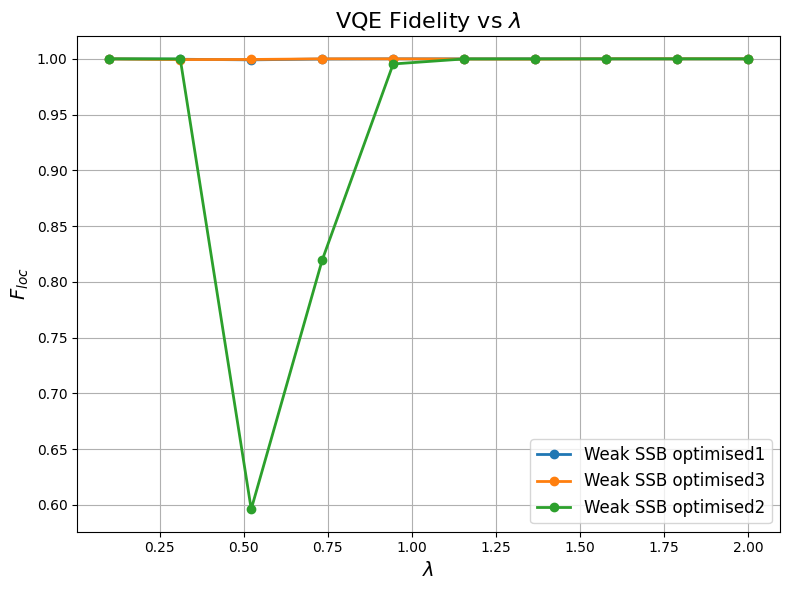

In [18]:
# ============================================================
# Plot : Fidelity vs lambda
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Collect data
# ------------------------------------------------------------

cases = {}

for r in all_results:

    label = r['case']

    if label not in cases:

        cases[label] = {
            'lambda': [],
            'fidelity': []
        }

    cases[label]['lambda'].append(r['lambda'])
    cases[label]['fidelity'].append(r['fidelity'])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

for label, data in cases.items():

    plt.plot(
        data['lambda'],
        data['fidelity'],
        marker='o',
        linewidth=2,
        label=label
    )

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel(r'$\lambda$', fontsize=14)

plt.ylabel(r'$F_{loc}$', fontsize=14)

plt.title(
    r'VQE Fidelity vs $\lambda$',
    fontsize=16
)

plt.grid(True)

plt.legend(fontsize=12)

plt.tight_layout()

plt.show()

In [19]:
# ============================================================
# H_c
# ============================================================

def two_site_hc(

    nq,

    mu=1.0,

    m0_sq=1.0,

    mI2=1.0
):

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(Nphi, format='csr', dtype=complex)

    Phi0 = kron(Phi, I, format='csr')

    Phi1 = kron(I, Phi, format='csr')

    Hc = (

        0.5 * (
            (Phi1 - Phi0) @ (Phi1 - Phi0)
        )

        +

        0.5 * (m0_sq - mI2) * (

            (Phi0 @ Phi0)

            +

            (Phi1 @ Phi1)
        )
    )

    return Hc


In [20]:
# ============================================================
# H_s
# ============================================================

def two_site_hs(

    nq,

    mu=1.0,

    mI2=1.0,

    m0_sq=1.0,

    lam=1.0,

    f=0.0,

    s=1.0
):

    Hloc = two_site_hloc(

        nq=nq,

        mu=mu,

        mI2=mI2,

        lam=lam,

        f=f
    )

    Hc = two_site_hc(

        nq=nq,

        mu=mu,

        m0_sq=m0_sq,

        mI2=mI2
    )

    return Hloc + s * Hc


In [21]:
# ============================================================
# Exact ground state
# ============================================================

def exact_ground_state(H):

    H_dense = H.toarray()

    eigvals, eigvecs = np.linalg.eigh(H_dense)

    return eigvals[0], eigvecs[:, 0]

In [22]:
# ============================================================
# Minimum instantaneous gap along adiabatic path
# ============================================================

def minimum_gap_along_path(

    nq,

    mu,

    mI2,

    m0_sq,

    lam,

    f,

    nsteps=100
):

    gap_min = 1e100

    for step in range(nsteps):

        s = step / nsteps

        Hs = two_site_hs(

            nq=nq,

            mu=mu,

            mI2=mI2,

            m0_sq=m0_sq,

            lam=lam,

            f=f,

            s=s
        )

        evals, _ = eigsh(

            Hs,

            k=2,

            which='SA'
        )

        evals = np.sort(np.real(evals))

        gap = evals[1] - evals[0]

        gap_min = min(gap_min, gap)

    return gap_min

In [23]:
# ============================================================
# One Trotter step
# ============================================================
from scipy.linalg import expm
def trotter_step_unitary(

    nq,

    dt,

    mu,

    mI2,

    m0_sq,

    lam,

    f,

    s
):

    Hs = two_site_hs(

        nq=nq,

        mu=mu,

        mI2=mI2,

        m0_sq=m0_sq,

        lam=lam,

        f=f,

        s=s
    )

    U = expm(

        -1j * Hs.toarray() * dt

    )

    return U


In [25]:
# ============================================================
# Adiabatic circuit evolution
# ============================================================

def adiabatic_circuit_evolution(

    initial_state,

    nq,

    T,

    mu,

    mI2,

    m0_sq,

    lam,

    f,

    nsteps=100
):

    nqubits = 2 * nq

    dt = T / nsteps

    psi = Statevector(initial_state)

    # --------------------------------------------------------
    # Time evolution
    # --------------------------------------------------------

    for step in range(nsteps):

        t = step * dt

        s = t / T

        # ----------------------------------------------------
        # Instantaneous unitary
        # ----------------------------------------------------

        U = trotter_step_unitary(

            nq=nq,

            dt=dt,

            mu=mu,

            mI2=mI2,

            m0_sq=m0_sq,

            lam=lam,

            f=f,

            s=s
        )

        # ----------------------------------------------------
        # Quantum circuit
        # ----------------------------------------------------

        qc = QuantumCircuit(nqubits)

        qc.unitary(U, range(nqubits))

        # ----------------------------------------------------
        # Evolve state
        # ----------------------------------------------------

        psi = psi.evolve(qc)

    return psi.data

In [26]:
# ============================================================
# T scan values
# ============================================================

T_values = [

    1,2,5,10,20,30,40,50,75,100,
    125,150,175,200,225,250,275,300,
    400,500,600,700,800,900,
    1000,1010,1020,1030,1040,1050,
    1060,1070,1080,1090,1100,
    1200,1300,1400,1500,
    2000,
    2100,2110,2120,2130,2140,
    2150,2160,2170,2180,2190,
    2200,2300,2400,2500,
    2600,2700,2800,2900,3000,4000
]

target_fidelity = 0.97

# ============================================================
# Storage
# ============================================================

adiabatic_results = []

# ============================================================
# MAIN LOOP
# ============================================================

for data in all_results:

    label   = data['case']
    lam     = data['lambda']
    mI2     = data['mI2']
    f       = data['f']
    psi_vqe = data['psi_vqe']

    print("\n")
    print("="*80)
    print(f"CASE   : {label}")
    print(f"lambda : {lam:.3f}")
    print("="*80)

    # ========================================================
    # Final Hamiltonian
    # ========================================================

    Hs_final = two_site_hs(

        nq=nq_site,

        mu=mu,

        mI2=mI2,

        m0_sq=1.0,

        lam=lam,

        f=f,

        s=1.0
    )

    E_exact_final, psi_exact_final = exact_ground_state(
        Hs_final
    )

    # ========================================================
    # Minimum gap along adiabatic path
    # ========================================================

    delta_min = minimum_gap_along_path(

        nq=nq_site,

        mu=mu,

        mI2=mI2,

        m0_sq=1.0,

        lam=lam,

        f=f,

        nsteps=100
    )

    print(f"Minimum path gap = {delta_min:.8e}")

    # ========================================================
    # Scan T
    # ========================================================

    Tmin_found = None
    best_fidelity = 0.0

    for T in T_values:

        psi_T = adiabatic_circuit_evolution(

            initial_state=psi_vqe,

            nq=nq_site,

            T=T,

            mu=mu,

            mI2=mI2,

            m0_sq=1.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        F = fidelity(
            psi_T,
            psi_exact_final
        )

        best_fidelity = max(
            best_fidelity,
            F
        )

        print(
            f"T = {T:<5} "
            f"Fidelity = {F:.8f}"
        )

        if F >= target_fidelity:

            Tmin_found = T
            break

    # ========================================================
    # Diagnostics
    # ========================================================

    P0 = None
    P1 = None
    P01 = None
    final_gap = None

    if Tmin_found is None:

        print("\nFAILED POINT DIAGNOSTICS")

        psi_T = adiabatic_circuit_evolution(

            initial_state=psi_vqe,

            nq=nq_site,

            T=3000,

            mu=mu,

            mI2=mI2,

            m0_sq=1.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        evals, evecs = eigsh(

            Hs_final,

            k=3,

            which='SA'
        )

        idx = np.argsort(evals)

        evals = evals[idx]
        evecs = evecs[:, idx]

        psi0 = evecs[:, 0]
        psi1 = evecs[:, 1]

        P0 = np.abs(np.vdot(psi0, psi_T))**2
        P1 = np.abs(np.vdot(psi1, psi_T))**2
        P01 = P0 + P1

        final_gap = evals[1] - evals[0]

        print(f"E1-E0  = {final_gap:.8e}")
        print(f"P0     = {P0:.8f}")
        print(f"P1     = {P1:.8f}")
        print(f"P0+P1  = {P01:.8f}")

    # ========================================================
    # Store
    # ========================================================

    adiabatic_results.append({

        'case': label,
        'lambda': lam,
        'mI2': mI2,
        'f': f,

        'Tmin': Tmin_found,

        'best_fidelity': best_fidelity,

        'delta_min': delta_min,

        'P0': P0,
        'P1': P1,
        'P01': P01,

        'final_gap': final_gap
    })

    print(
        f"\nMinimum T for Fidelity >= 0.97 : "
        f"{Tmin_found}"
    )

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*180)
print("FINAL ADIABATIC SUMMARY")
print("="*180)

print(

    f"{'Case':<15}"
    f"{'lambda':<10}"
    f"{'T_min':<10}"
    f"{'Best Fidelity':<18}"
    f"{'Delta_min':<18}"
    f"{'P0':<12}"
    f"{'P1':<12}"
    f"{'P0+P1':<12}"
)

print("="*180)

for r in adiabatic_results:

    print(

        f"{r['case']:<15}"
        f"{r['lambda']:<10.3f}"
        f"{str(r['Tmin']):<10}"
        f"{r['best_fidelity']:<18.10f}"
        f"{r['delta_min']:<18.8e}"
        f"{str(None if r['P0'] is None else round(r['P0'],6)):<12}"
        f"{str(None if r['P1'] is None else round(r['P1'],6)):<12}"
        f"{str(None if r['P01'] is None else round(r['P01'],6)):<12}"
    )



CASE   : Weak SSB optimised1
lambda : 0.100
Minimum path gap = 8.89252645e-02
T = 1     Fidelity = 0.00000000
T = 2     Fidelity = 0.00000000
T = 5     Fidelity = 0.00062276
T = 10    Fidelity = 0.00012338
T = 20    Fidelity = 0.00174584
T = 30    Fidelity = 0.01683275
T = 40    Fidelity = 0.02471866
T = 50    Fidelity = 0.05089025
T = 75    Fidelity = 0.37221370
T = 100   Fidelity = 0.53311701
T = 125   Fidelity = 0.42265361
T = 150   Fidelity = 0.51805700
T = 175   Fidelity = 0.59342120
T = 200   Fidelity = 0.62103988
T = 225   Fidelity = 0.62893065
T = 250   Fidelity = 0.58617144
T = 275   Fidelity = 0.66866368
T = 300   Fidelity = 0.69091118
T = 400   Fidelity = 0.65110867
T = 500   Fidelity = 0.78159055
T = 600   Fidelity = 0.79949560
T = 700   Fidelity = 0.74435511
T = 800   Fidelity = 0.79599684
T = 900   Fidelity = 0.87347925
T = 1000  Fidelity = 0.83940178
T = 1010  Fidelity = 0.74070838
T = 1020  Fidelity = 0.70655287
T = 1030  Fidelity = 0.86226386
T = 1040  Fidelity = 0.7

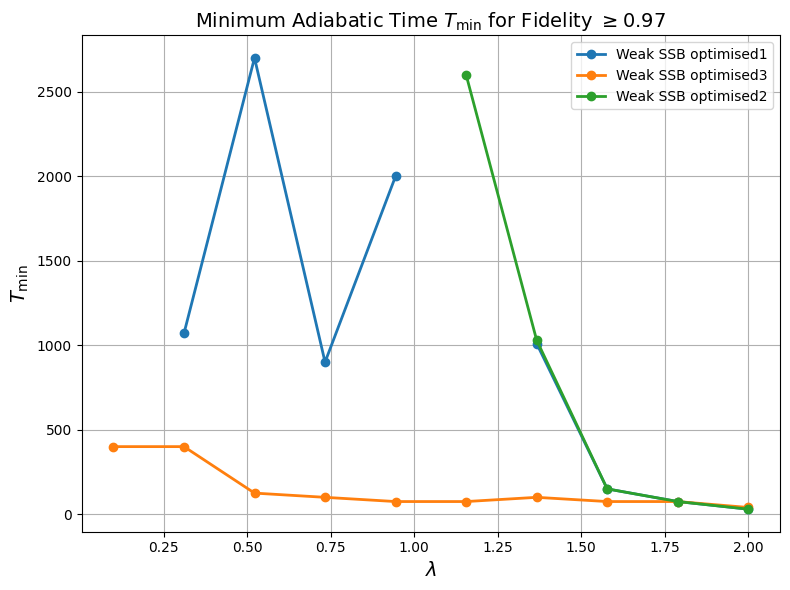

In [28]:
# ============================================================
# Plot T_min vs lambda
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# Separate data by case
# ============================================================

case_data = {}

for r in adiabatic_results:

    case = r['case']

    if case not in case_data:

        case_data[case] = {

            'lambda': [],

            'Tmin': []
        }

    case_data[case]['lambda'].append(

        r['lambda']
    )

    case_data[case]['Tmin'].append(

        r['Tmin']
    )

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8,6))

for case, d in case_data.items():

    plt.plot(

        d['lambda'],

        d['Tmin'],

        marker='o',

        linewidth=2,

        label=case
    )

# ============================================================
# Labels
# ============================================================

plt.xlabel(r'$\lambda$', fontsize=14)

plt.ylabel(r'$T_{\min}$', fontsize=14)

plt.title(

    r'Minimum Adiabatic Time $T_{\min}$ '
    r'for Fidelity $\geq 0.97$',

    fontsize=14
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()